In [81]:
last_pre_week = "2026-05-24"
test_df_start = "2026-05-01"
base_PoM_default = {'dav2shreths':0.16, 'sharethis': 0.15}

In [82]:
#adv_type = "Automotive"
adv_type = "All"

In [83]:
data_path = "/Users/ravirajan/code/data"
output_path = "/Users/ravirajan/code/outputs"

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [85]:
import matplotlib

In [86]:
import seaborn as sns

In [87]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [88]:
#dat0 = pd.read_csv(f"{data_path}/TTD-20260608.csv", low_memory=False).replace(' ', None)
dat0 = pd.read_csv(f"{data_path}/TTD-20260615.csv", low_memory=False).replace(' ', None)
pricing = pd.read_csv(f"{data_path}/Price_Expt_Assignments2.csv")

In [89]:
dat0.head()

,Active_ID_Count,Active_ID_Count_Percentile,Advertiser_Category,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Percentile,Avg_Value_Score,Data_Cost,Effective_Impression_Count,Full_Path,...,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,Received_ID_Count,Selected_Pct,Selected_Pct_Percentile,Third_Party_Data_Provider_Element_Id,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Week_Start_Date
0,NaN,NaN,Business and Finance,3.2,67.0,NaN,NaN,NaN,NaN,Data Alliance > Retail > Interest > Global > M...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
1,NaN,NaN,Style & Fashion,3.5,76.1,NaN,NaN,NaN,NaN,Data Alliance > Retail > Interest > Global > S...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
2,NaN,NaN,Style & Fashion,3.8,81.5,NaN,NaN,NaN,NaN,Data Alliance > Sports > Interest > Global > T...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
3,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,NaN,Data Alliance > Education > Interest > Global ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00
4,NaN,NaN,Style & Fashion,3.8,81.7,NaN,NaN,NaN,NaN,Data Alliance > Education > Interest > Global ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dav2shreths,None,2026-01-05 00:00:00+00


In [90]:
pricing.head()    

,Unnamed: 0.1,Unnamed: 0,Third_Party_Data_Provider_Id,group,Full_Path,revenue,rev_rank,geo,assignment,incr,bucket
0,0,0.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,2421.51,1,Global,1,0.05,high
1,1,2.0,dav2shreths,0,Data Alliance > Demographic > Interest > Globa...,1983.75,2,Global,-1,0.05,high
2,2,1.0,dav2shreths,0,Data Alliance > Business & Finance > Interest ...,1336.34,3,Global,0,0.05,high
3,3,4.0,dav2shreths,1,Data Alliance > Demographic > Interest > Globa...,1230.68,4,Global,0,0.05,high
4,4,3.0,dav2shreths,1,Data Alliance > Travel > Interest > Global > A...,1081.20,5,Global,1,0.05,high


In [91]:
dat = pd.DataFrame(dat0, copy=True) # prices changed 5-26 so capturing weeks from 5-18
dat['post'] = dat['Week_Start_Date'].apply(lambda x: 1 if x > last_pre_week else 0)

In [92]:
def add_prices(dat, base_PoM_default, pricing):
    dat = dat.set_index('Third_Party_Data_Provider_Id').join(pd.DataFrame([base_PoM_default]).T[[0]]).reset_index()
    cols = list(dat.columns)
    cols[-1] = 'base_PoM'
    dat.columns = cols
    #
    pricing['delta'] = pricing['assignment'] * pricing['incr']
    dat = dat.set_index(['Full_Path', 'Third_Party_Data_Provider_Id']).join(
        pricing.set_index(['Full_Path', 'Third_Party_Data_Provider_Id'])[['group', 'delta', 'bucket']], how='left').reset_index()
    dat['delta'] = dat['delta'].fillna(0)
    dat['price'] = dat['base_PoM'] + dat['delta'] * dat['post']  # delta only applies post-treatment
    return dat


In [93]:
dat = add_prices(dat, base_PoM_default, pricing)

In [94]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [95]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [96]:
dat.groupby('geo')[['Data_Cost']].sum() / dat['Data_Cost'].sum()

,Data_Cost
geo,
APAC,0.014003
Asia,0.014293
Global,0.479216
US,0.326643
Unknown,0.165845


In [97]:
dat.groupby('geo')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
APAC,3780.0,0.150000,1.063179e-14,0.15,0.15,0.15,0.15,0.15
Asia,384300.0,0.150016,4.045567e-04,0.15,0.15,0.15,0.15,0.16
Global,996345.0,0.156775,8.541692e-03,0.10,0.15,0.16,0.16,0.21
US,261765.0,0.150000,7.408255e-13,0.15,0.15,0.15,0.15,0.15
Unknown,161430.0,0.150020,4.413065e-04,0.15,0.15,0.15,0.15,0.16


In [98]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [99]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3208, 19, 82)

# EDA

In [100]:
dat1 = dat[dat.Received_ID_Count.isna() == False]
dat1 = dat1[dat1.Advertiser_Category == adv_type]  
dat1.shape

(81421, 33)

In [101]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [102]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

<Axes: title={'center': 'avg(revenue) over time'}, xlabel='week_start', ylabel='revenue'>

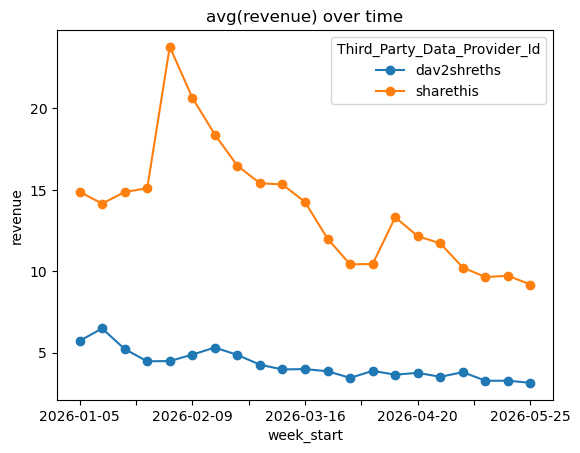

In [103]:
get_split_means(dat1, value = 'Data_Cost').plot(marker='o', title='avg(revenue) over time', ylabel='revenue')

<Axes: xlabel='week_start'>

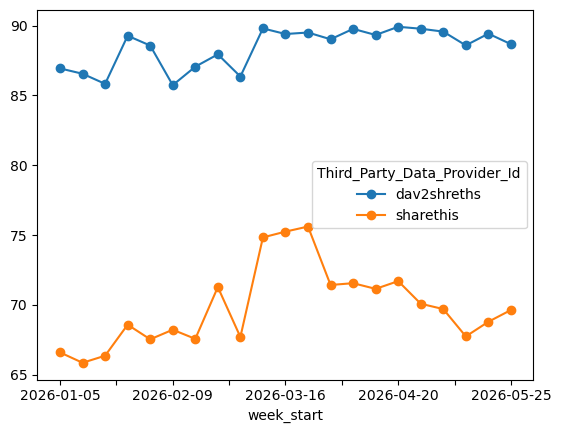

In [104]:
get_split_means(dat1, value = 'Avg_Relevance_Percentile').plot(marker='o')

## filter out bad rows

In [105]:
#dat1.head()

In [106]:
dat2 = dat1[dat1.Received_ID_Count > 0]

# also filter out rows not belonging to pricing experiment
dat2 = dat2[~dat2.group.isna()]

# Model

In [107]:
yr = dat2['Avg_Relevance_Percentile'] #['Avg_Relevance']
yd = dat2['Data_Cost'].astype(float) 

In [108]:
#seg_col = 'segment_last'
seg_col = 'segment_2'
#seg_col = 'Full_Path'

In [109]:
x_c_cols = list(dict.fromkeys([seg_col, 'week_start', 'Advertiser_Category', 'Third_Party_Data_Provider_Id', 'geo', 'segment_2']))
x_n_cols = ['Received_ID_Count', 'price', 'Avg_Relevance_Percentile'] #[ 'Active_ID_Count_Percentile', 'Paid_Pct_Percentile']
# 'Avg_Value_Percentile' has NAs

In [110]:
Xn = pd.DataFrame(dat2[x_n_cols], dtype=float)
Xn['log_Received_ID_Count'] = Xn['Received_ID_Count'].apply(lambda x: np.log(x))
x_n_cols += ['log_Received_ID_Count']

In [111]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xn = pd.DataFrame(sc.fit_transform(Xn), columns=Xn.columns, index=Xn.index)

In [112]:
Xc = pd.get_dummies(dat2[x_c_cols])

In [113]:
X = Xn.join(Xc)
X.head()

,Received_ID_Count,price,Avg_Relevance_Percentile,log_Received_ID_Count,segment_2_arts&entertainment,segment_2_automotive,segment_2_autos&vehicles,segment_2_beauty&fitness,segment_2_books&literature,segment_2_business&finance,...,week_start_2026-04-20,week_start_2026-04-27,week_start_2026-05-04,week_start_2026-05-11,week_start_2026-05-18,week_start_2026-05-25,Advertiser_Category_All,Third_Party_Data_Provider_Id_dav2shreths,Third_Party_Data_Provider_Id_sharethis,geo_Global
246,-1.084075,0.519744,0.749684,-1.068907,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
378,-1.238617,0.519744,0.573604,-1.965256,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
379,-0.904363,0.519744,0.525583,-0.585065,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True
397,-1.137060,0.519744,0.829720,-1.285068,False,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
436,1.451356,0.519744,-1.699421,1.047845,False,False,False,False,False,True,...,False,False,False,False,False,False,True,True,False,True


# Revenue model

## Ridge

In [114]:
from sklearn.linear_model import Ridge

mod_d = Ridge(alpha=0.000001)
mod_d.fit(X, yd)
mod_d.score(X, yd)

0.02611301100904162

In [115]:
coef_d = pd.DataFrame(mod_d.coef_, index=X.columns, columns=['beta'])
coef_d['abs_beta'] = coef_d['beta'].abs()
coef_d_sorted = coef_d.sort_values('abs_beta', ascending=False)

In [116]:
coef_d_sorted[coef_d_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_2_people&society,82.005869,82.005869
segment_2_travel,48.188777,48.188777
segment_2_demographic,39.764887,39.764887
segment_2_validateddemographic,36.753222,36.753222
segment_2_law&government,16.070691,16.070691
segment_2_business&finance,15.636191,15.636191
segment_2_realestate,14.293693,14.293693
segment_2_hobbies&leisure,5.999139,5.999139
segment_2_health&wellness,5.684437,5.684437
segment_2_career&jobs,4.798515,4.798515


### some interesting betas

In [117]:
coef_d.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,8.796492,8.796492
log_Received_ID_Count,2.941727,2.941727


In [118]:
coef_d.filter(regex='Rel', axis='index')

,beta,abs_beta
Avg_Relevance_Percentile,4.073632,4.073632


In [119]:
coef_d.filter(regex='price', axis='index')

,beta,abs_beta
price,-0.382961,0.382961


In [120]:
coef_d.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_Global,0.0,0.0


In [121]:
coef_d.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,-3.265936,3.265936
Third_Party_Data_Provider_Id_sharethis,3.265890,3.265890


In [122]:
import matplotlib.pyplot as plt

def dfScatter(df, xcol='beta', ycol='Received_ID_Count', catcol='criterion', logx=False, logy=False):
    #fig, ax = plt.subplots()
    categories = np.unique(df[catcol])
    colors = np.linspace(0, 1, len(categories))
    colordict = dict(zip(categories, colors))  
    colors = df[catcol].apply(lambda x: colordict[x])
    return df.plot(kind='scatter', x=xcol, y=ycol, logy=logy, logx=logx, c=colors)

# RF to forecast demand curves

In [123]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [124]:
X_rf = X[X.columns[X.columns != 'log_Received_ID_Count']]

In [125]:
mod_d_rf = RFR(max_depth=5)
mod_d_rf.fit(X_rf, yd)
mod_d_rf.score(X_rf, yd)

0.39340312647792874

In [126]:
coef_d_rf = pd.DataFrame(mod_d_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_d_rf_sorted = coef_d_rf.sort_values('feature_importance', ascending=False)
coef_d_rf_sorted.head(20)

,feature_importance
Received_ID_Count,0.534094
Avg_Relevance_Percentile,0.245713
week_start_2026-02-09,0.044284
week_start_2026-02-16,0.036604
week_start_2026-02-02,0.028544
segment_2_people&society,0.020267
segment_2_travel,0.019794
week_start_2026-02-23,0.013878
week_start_2026-01-26,0.010435
week_start_2026-01-05,0.009843


In [127]:
def sweep_forecast(X_rf, mod, sc, 
                   vary_feature, grid_unscaled, 
                   n_rows=1000,
                   geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
                  ):
    """
    Sweep vary_feature across grid_unscaled, averaging revenue over n_rows real data rows.

    vary_feature : numeric feature name in sc.feature_names_in_
                   e.g. 'Received_ID_Count', 'price', 'Avg_Relevance_Percentile'
    grid_unscaled: array of raw (unscaled) values to sweep over
    n_rows       : number of real data rows to average over

    Returns DataFrame with columns: [vary_feature + '_unscaled', 'geo', 'revenue_forecast']
    """
    grid_unscaled = np.asarray(grid_unscaled)
    feat_idx = list(sc.feature_names_in_).index(vary_feature)
    grid_scaled = (grid_unscaled - sc.mean_[feat_idx]) / sc.scale_[feat_idx]

    X_rf2 = X_rf[X_rf.columns[X_rf.columns != vary_feature]]
    
    forecast_list = []
    for idx in range(min(n_rows, len(X_rf2))):
        samples_vary = pd.DataFrame(
            {vary_feature: grid_scaled},
            index=[X_rf2.index[idx]] * len(grid_scaled)
        )
        temp = samples_vary.join(X_rf2.iloc[[idx]])
        forecast_list.append(temp)

    fc = pd.concat(forecast_list)
    fc['revenue_forecast'] = mod.predict(fc[X_rf.columns])
    fc[vary_feature + '_unscaled'] = fc[vary_feature] * sc.scale_[feat_idx] + sc.mean_[feat_idx]
    fc['geo'] = fc.reindex(columns=geos).apply(
        lambda x: next((g.split('_')[1] for g in geos if x[g] == 1), 'Unknown'), axis=1
    )

    return fc.groupby(['geo', vary_feature + '_unscaled'])[['revenue_forecast']].mean().reset_index()


In [128]:
def extract_geo(x, geos):
    for geo in geos:
        if x[geo] == 1:
            return geo.split('_')[1]
    return "Unknown"

geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']


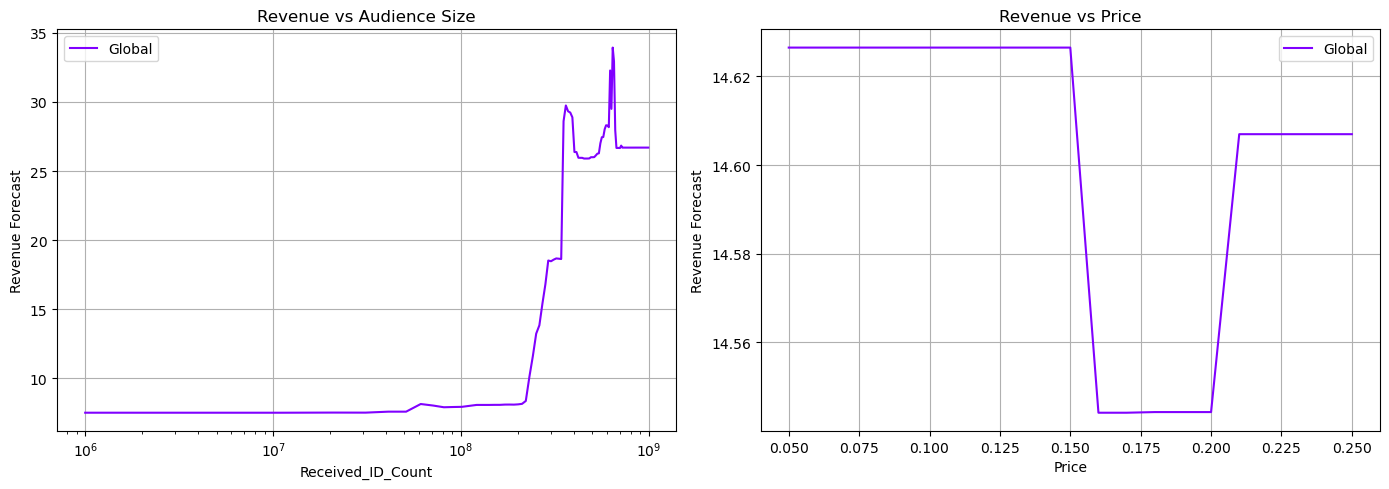

In [129]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Size sweep ---
size_grid = np.arange(1, 1000, 10) * 1_000_000
fc_size = sweep_forecast(X_rf, mod_d_rf, sc, 'Received_ID_Count', size_grid)
geos = fc_size['geo'].unique()
color = plt.cm.rainbow(np.linspace(0, 1, len(geos)))
for i, geo in enumerate(geos):
    sub = fc_size[fc_size['geo'] == geo]
    axes[0].plot(sub['Received_ID_Count_unscaled'], sub['revenue_forecast'], label=geo, color=color[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('Received_ID_Count')
axes[0].set_ylabel('Revenue Forecast')
axes[0].set_title('Revenue vs Audience Size')
axes[0].legend()
axes[0].grid(True)

# --- Price sweep ---
price_grid = np.arange(0.05, 0.26, 0.01)
fc_price = sweep_forecast(X_rf, mod_d_rf, sc, 'price', price_grid)
geos_p = fc_price['geo'].unique()
color_p = plt.cm.rainbow(np.linspace(0, 1, len(geos_p)))
for i, geo in enumerate(geos_p):
    sub = fc_price[fc_price['geo'] == geo]
    axes[1].plot(sub['price_unscaled'], sub['revenue_forecast'], label=geo, color=color_p[i])
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Revenue Forecast')
axes[1].set_title('Revenue vs Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## DID

In [130]:
test = dat[~dat.group.isna()]
test = test[test.Week_Start_Date > test_df_start]
test = test[test.Third_Party_Data_Provider_Id == 'sharethis']
test_means = test.groupby(['group', 'Full_Path', 'delta', 'post'])[['Data_Cost']].mean()

In [131]:
test_means_joined = test_means.xs(0, level='post').join(
    test_means.xs(1, level='post'), lsuffix='_pre', rsuffix='_post'
).reset_index()
test_means_joined['chg'] = test_means_joined['Data_Cost_post'] - test_means_joined['Data_Cost_pre']
test_means_joined['chg_ratio'] = test_means_joined['chg'] / test_means_joined['Data_Cost_pre']

In [132]:
test_means_joined.groupby('delta')[['chg']].describe()

chg                                                                 \
       count      mean        std         min       25%       50%       75%   
delta                                                                         
-0.05  218.0  1.073378   9.515873  -51.548881 -0.051667  0.000000  0.571071   
 0.00  232.0 -0.186882   3.749439  -28.152121 -0.287500 -0.003333  0.050000   
 0.05  232.0 -1.642546  10.728389 -116.744444 -0.761667 -0.053889  0.000000   

                  
             max  
delta             
-0.05  73.680000  
 0.00  27.938444  
 0.05  69.646667

         did                                                     
       count   mean     std      min    25%    50%    75%     max
delta                                                            
-0.05  193.0  1.439  11.364  -79.487 -0.197  0.057  1.014  73.193
 0.00  232.0  0.000   0.000    0.000  0.000  0.000  0.000   0.000
 0.05  198.0 -1.665  11.574 -112.370 -1.327 -0.036  0.245  62.561


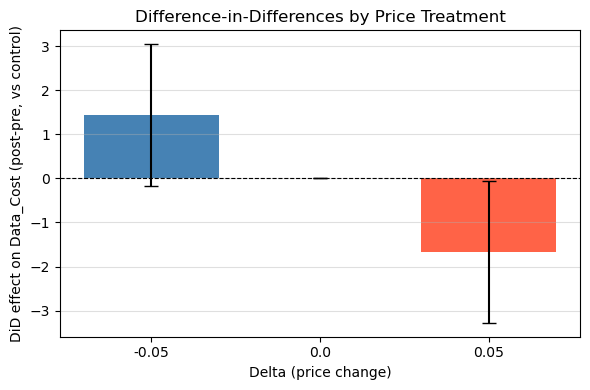

In [133]:
# DiD: within each group, subtract the control (delta=0) mean chg
# This removes group-level time trends common to all Full_Paths in that group

control_mean_by_group = (
    test_means_joined[test_means_joined['delta'] == 0]
    .groupby('group')['chg']
    .mean()
    .rename('control_chg_mean')
)

did = (
    test_means_joined #[test_means_joined['delta'] != 0]
    .join(control_mean_by_group, on='group')
    .dropna(subset=['control_chg_mean'])
    .copy()
)
did['did'] = did['chg'] - did['control_chg_mean']

# Summary per delta
print(did.groupby('delta')[['did']].describe().round(3))

# Plot: mean DiD with 95% CI per delta
import matplotlib.pyplot as plt
from scipy import stats

deltas = sorted(did['delta'].unique())
means = [did[did['delta'] == d]['did'].mean() for d in deltas]
sems  = [stats.sem(did[did['delta'] == d]['did'].dropna()) for d in deltas]
cis   = [1.96 * s for s in sems]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(d) for d in deltas], means, yerr=cis, capsize=5, color=['steelblue', 'brown', 'tomato'])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Delta (price change)')
ax.set_ylabel('DiD effect on Data_Cost (post-pre, vs control)')
ax.set_title('Difference-in-Differences by Price Treatment')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

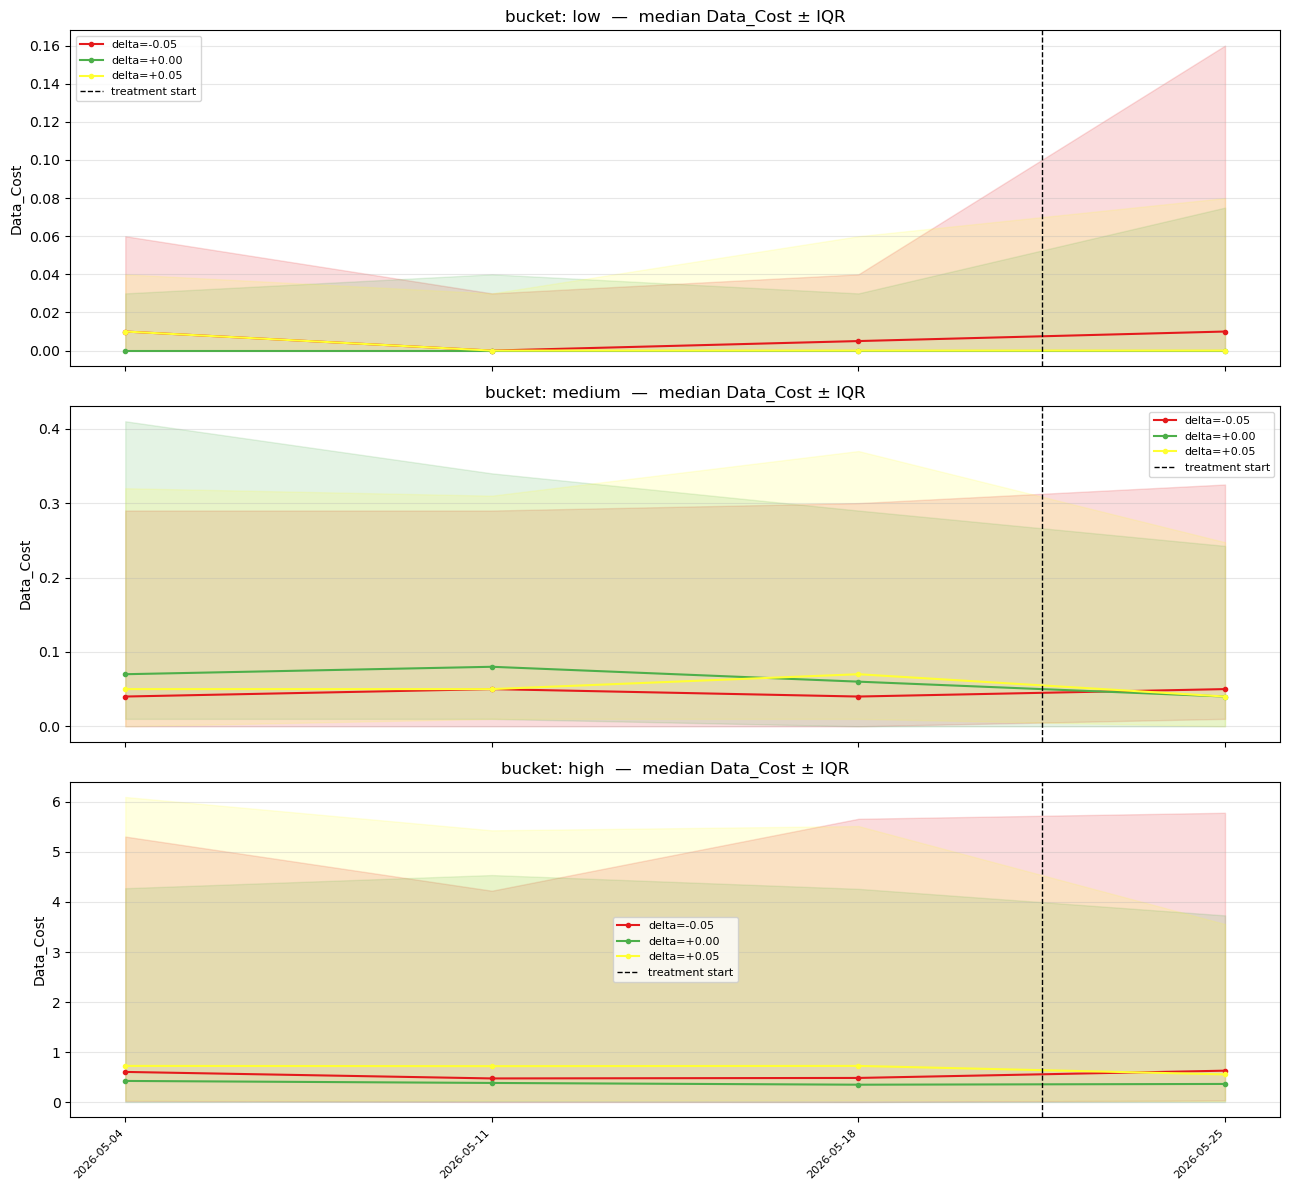

In [134]:
import matplotlib.pyplot as plt

buckets = ['low', 'medium', 'high']
delta_vals = sorted(test['delta'].unique())
dates_all = sorted(test['Week_Start_Date'].unique())
xs = list(range(len(dates_all)))
colors = plt.cm.Set1([0, 0.33, 0.66])  # one color per delta

fig, axes = plt.subplots(len(buckets), 1, figsize=(13, 4 * len(buckets)), sharex=True)

for ax, bucket in zip(axes, buckets):
    sub = test[test['bucket'] == bucket]

    for color, delta in zip(colors, delta_vals):
        grp = sub[sub['delta'] == delta].groupby('Week_Start_Date')['Data_Cost']
        medians = [grp.get_group(d).median() if d in grp.groups else np.nan for d in dates_all]
        q25     = [grp.get_group(d).quantile(0.25) if d in grp.groups else np.nan for d in dates_all]
        q75     = [grp.get_group(d).quantile(0.75) if d in grp.groups else np.nan for d in dates_all]

        ax.plot(xs, medians, marker='o', markersize=3, linewidth=1.5,
                label=f'delta={delta:+.2f}', color=color)
        ax.fill_between(xs, q25, q75, alpha=0.15, color=color)

    treat_idx = next((i for i, d in enumerate(dates_all) if str(d) > last_pre_week), None)
    if treat_idx is not None:
        ax.axvline(treat_idx - 0.5, color='black', linestyle='--', linewidth=1, label='treatment start')

    ax.set_title(f'bucket: {bucket}  —  median Data_Cost ± IQR')
    ax.set_ylabel('Data_Cost')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xticks(xs)
axes[-1].set_xticklabels([str(d)[:10] for d in dates_all], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
